In [2]:
## Fig4 空转 + PNI niche。
## A 旭日  B 病理（脚本不做）  C 相关  D 平均 r  E 组成  F Unique vs Other 施万  G 四张空间
## 每张切片自己的邻域（公开 Epi-*，CosMx 用 epi.sub），不用 s1–s5，不预先定亚型。
## 公开 H2：Club→Luminal，Hillock→Basal，NE 留下；T 系/髓系合并。
## 缓存：output/13/public_niche.rds、per_sample/、cosmx_niche_slim.rds、fig4_aligned.rds、cosmx_xy_spatial.rds
## 有缓存且 version 对得上就只读画图。重算邻域：rebuild_niche <- TRUE
## 只重算对齐/相关：rebuild_aligned <- TRUE
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggsci)
library(ggsignif)
library(ggnewscale)
library(patchwork)
library(scales)
library(data.table)
library(jsonlite)
library(ComplexHeatmap)
library(circlize)
library(grid)

root <- "/home/data/tanglei01/project/Prostate_atlas"
outd <- file.path(root, "output/13")
dir.create(file.path(outd, "per_sample"), recursive = TRUE, showWarnings = FALSE)

rebuild_niche <- FALSE
rebuild_aligned <- FALSE
cache_ver <- "v3_localEpi_noS"

align_lv <- c(
  "B cell", "Basal cell", "Endothelial cell", "Fibroblast", "Luminal cell",
  "Macrophage", "Mast cell", "Neuroendocrine cell", "Pericyte",
  "Schwann cell", "Smooth muscle cell", "T cell"
)
align_lab <- c(
  `B cell` = "B", `Basal cell` = "Basal", `Endothelial cell` = "Endo",
  Fibroblast = "Fibro", `Luminal cell` = "Luminal", Macrophage = "Mac",
  `Mast cell` = "Mast", `Neuroendocrine cell` = "NE", Pericyte = "Pericyte",
  `Schwann cell` = "Schwann", `Smooth muscle cell` = "SMC", `T cell` = "T"
)
collapse_map <- c(
  `B cell` = "B cell", `Basal cell` = "Basal cell",
  `Hillock cell` = "Basal cell",
  `Endothelial cell` = "Endothelial cell", Fibroblast = "Fibroblast",
  `Luminal cell` = "Luminal cell", `Club cell` = "Luminal cell",
  Macrophage = "Macrophage", Monocyte = "Macrophage", `Dendritic cell` = "Macrophage",
  `Mast cell` = "Mast cell", `Neuroendocrine cell` = "Neuroendocrine cell",
  Pericyte = "Pericyte", `Schwann cell` = "Schwann cell",
  `Smooth muscle cell` = "Smooth muscle cell",
  `CD4 T cell` = "T cell", `CD8 T cell` = "T cell",
  `Gamma delta T cell` = "T cell", `Natural killer cell` = "T cell"
)
h2_lv <- c(
  "B cell", "Basal cell", "CD4 T cell", "CD8 T cell", "Club cell",
  "Dendritic cell", "Endothelial cell", "Fibroblast", "Gamma delta T cell",
  "Hillock cell", "Luminal cell", "Macrophage", "Mast cell", "Monocyte",
  "Natural killer cell", "Neuroendocrine cell", "Pericyte", "Schwann cell",
  "Smooth muscle cell"
)
type_ord <- c(
  "Normal_DB", "Naive_BPH", "5aTreat_BPH", "Naive_PC", "PNI_PC",
  "Per_PC_DB", "NeoADT_PC", "CRPC_DB", "Met_PC"
)
type_lab <- c(
  Normal_DB = "Normal DB", Naive_BPH = "BPH", `5aTreat_BPH` = "5ARI BPH",
  Naive_PC = "Naive PC", PNI_PC = "PNI PC", Per_PC_DB = "Peri PC",
  NeoADT_PC = "NeoADT", CRPC_DB = "CRPC DB", Met_PC = "Met PC"
)
study_lab <- c(
  GSE179615 = "GSE179615", GSE181294 = "GSE181294",
  GSE278936 = "GSE278936", `In-house` = "In-house"
)
pni_lab <- c(`1` = "PNI", `0` = "Naive")
cols_pni <- c(PNI = "#E64B35", Naive = "#3C5488")
r_um <- 105
nmf_k <- 6
query_type <- "Luminal cell"
anno_col <- "rctd_H2_first_type"
`%||%` <- function(a, b) if (is.null(a)) b else a
th <- theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", size = 13),
        legend.title = element_blank())
cols_tech <- c(Visium = "#4DBBD5", `Slide-seq` = "#00A087", CosMx = "#E64B35")

pub_rds <- file.path(outd, "public_niche.rds")
slim_rds <- file.path(outd, "cosmx_niche_slim.rds")
aligned_rds <- file.path(outd, "fig4_aligned.rds")


In [3]:
collapse_mat <- function(m, to_lv = align_lv) {
  z <- matrix(0, nrow = length(to_lv), ncol = ncol(m),
              dimnames = list(to_lv, colnames(m)))
  for (ct in rownames(m)) {
    tgt <- unname(collapse_map[ct])
    if (is.na(tgt)) next
    z[tgt, ] <- z[tgt, ] + as.numeric(m[ct, ])
  }
  cs <- colSums(z)
  for (j in seq_len(ncol(z))) if (cs[j] > 0) z[, j] <- z[, j] / cs[j]
  z
}

align_types <- function(m, lv) {
  z <- matrix(0, nrow = length(lv), ncol = ncol(m), dimnames = list(lv, colnames(m)))
  common <- intersect(rownames(m), lv)
  if (length(common)) z[common, ] <- as.matrix(m[common, , drop = FALSE])
  z
}

load_catalog <- function() {
  catj <- fromJSON(file.path(root, "vis/portal/data/spatial_catalog.json"),
                   simplifyDataFrame = FALSE)
  rows <- list()
  for (tech in catj$technologies) {
    for (tp in tech$types) {
      for (s in tp$samples) {
        rows[[length(rows) + 1L]] <- data.table(
          tech = tech$id, type = tp$id, id = s$id,
          study = s$study %||% NA_character_
        )
      }
    }
  }
  sec <- rbindlist(rows)
  sec[, type := factor(type, levels = intersect(type_ord, unique(type)))]
  sec[, tech := factor(tech, levels = c("Visium", "Slide-seq", "CosMx"))]
  sec[, study := fifelse(study %in% names(study_lab), study, "In-house")]
  sec[, study := factor(study, levels = names(study_lab))]
  sec
}


In [4]:
## 邻域：已有 public_niche.rds + 72 个 per_sample 就跳过。
ensure_public_niche <- function() {
  if (file.exists(pub_rds) && !rebuild_niche) {
    message("load ", pub_rds)
    return(readRDS(pub_rds))
  }
  suppressPackageStartupMessages({
    library(Seurat)
    library(qs)
    library(dbscan)
  })
  CalNichMatrix <- function(seu, query.cells, r = 80, reduction = "spatial",
                            anno_col = "annotation") {
    coords <- Seurat::Embeddings(seu, reduction = reduction)
    ref.cells <- rownames(coords)
    query.cells <- intersect(query.cells, ref.cells)
    annotation <- seu@meta.data[[anno_col]]
    if (!is.factor(annotation)) annotation <- factor(annotation)
    type.levels <- levels(annotation)
    type.int <- setNames(match(as.character(annotation), type.levels),
                         rownames(seu@meta.data))
    Q <- coords[query.cells, , drop = FALSE]
    nbrs <- dbscan::frNN(coords, eps = r, query = Q, sort = FALSE)
    niche.list <- lapply(nbrs$id, function(nn) {
      if (!length(nn)) integer(length(type.levels))
      else tabulate(type.int[ref.cells[nn]], nbins = length(type.levels))
    })
    niche.mat <- do.call(rbind, niche.list)
    rownames(niche.mat) <- rownames(Q)
    colnames(niche.mat) <- type.levels
    rs <- rowSums(niche.mat)
    niche.mat.norm <- niche.mat
    nz <- rs > 0
    niche.mat.norm[nz, ] <- niche.mat[nz, , drop = FALSE] / rs[nz]
    list(niche.mat = niche.mat, niche.mat.norm = niche.mat.norm)
  }
  RunNMF <- function(niche.mat, k = 5, cores = 2, seed = 1024) {
    RcppML::setRcppMLthreads(cores)
    model <- RcppML::nmf(niche.mat, k = k, verbose = FALSE, seed = seed)
    H <- model$h
    rownames(H) <- paste0("factor_", seq_len(nrow(H)))
    colnames(H) <- colnames(niche.mat)
    W <- model$w
    rownames(W) <- rownames(niche.mat)
    colnames(W) <- rownames(H)
    list(W = W, H = H)
  }
  get_rctd_w <- function(seu) {
    W <- seu@misc$rctd_weights_H2
    if (is.null(W)) {
      W <- t(as.matrix(GetAssayData(seu, assay = "RCTD_H2", layer = "data")))
    }
    W <- as.matrix(W)
    z <- matrix(0, nrow = nrow(W), ncol = length(h2_lv),
                dimnames = list(rownames(W), h2_lv))
    common <- intersect(colnames(W), h2_lv)
    z[, common] <- W[, common, drop = FALSE]
    rs <- rowSums(z)
    ok <- rs > 0
    z[ok, ] <- z[ok, , drop = FALSE] / rs[ok]
    z
  }
  rctd_hex_niche <- function(seu, query, r = 105, W) {
    coords <- Seurat::Embeddings(seu, "physical")
    cells <- intersect(rownames(coords), rownames(W))
    coords <- coords[cells, , drop = FALSE]
    W <- W[cells, , drop = FALSE]
    query <- intersect(query, cells)
    Q <- coords[query, , drop = FALSE]
    nbrs <- dbscan::frNN(coords, eps = r, query = Q, sort = FALSE)
    mat <- t(vapply(seq_along(nbrs$id), function(i) {
      nn <- nbrs$id[[i]]
      if (!length(nn)) return(rep(0, ncol(W)))
      colMeans(W[nn, , drop = FALSE])
    }, numeric(ncol(W))))
    rownames(mat) <- query
    colnames(mat) <- colnames(W)
    list(mat = mat, n_nn = vapply(nbrs$id, length, integer(1)))
  }
  cluster_niches <- function(mat_n, seu) {
    n <- nrow(mat_n)
    if (n < 3L) {
      epi.sub <- factor(rep("Epi-0", n), levels = "Epi-0")
      names(epi.sub) <- rownames(mat_n)
      return(list(epi.sub = epi.sub, k = NA_integer_, n_used = n))
    }
    k_use <- min(nmf_k, max(2L, ncol(mat_n) - 1L), n - 1L)
    nmf <- tryCatch(RunNMF(mat_n, k = k_use, cores = 2L, seed = 1024),
                    error = function(e) e)
    if (inherits(nmf, "error")) {
      epi.sub <- factor(rep("Epi-0", n), levels = "Epi-0")
      names(epi.sub) <- rownames(mat_n)
      return(list(epi.sub = epi.sub, k = NA_integer_, n_used = n))
    }
    seu.epi <- subset(seu, cells = rownames(nmf$W))
    seu.epi[["nmf"]] <- CreateDimReducObject(
      embeddings = nmf$W, key = "factor_", assay = DefaultAssay(seu.epi)
    )
    seu.epi <- FindNeighbors(seu.epi, reduction = "nmf",
                             dims = seq_len(k_use), verbose = FALSE)
    seu.epi <- FindClusters(seu.epi, resolution = 0.1,
                            algorithm = 1, verbose = FALSE)
    epi.sub <- factor(paste0("Epi-", as.character(seu.epi$seurat_clusters)))
    names(epi.sub) <- colnames(seu.epi)
    list(epi.sub = epi.sub, k = k_use, n_used = n)
  }
  avg_by_cluster <- function(mat, epi.sub, gsm) {
    cl <- levels(droplevels(epi.sub))
    avg <- sapply(cl, function(lv) {
      cells <- names(epi.sub)[epi.sub == lv]
      z <- colMeans(mat[cells, , drop = FALSE])
      s <- sum(z)
      if (s <= 0) z else z / s
    })
    if (is.null(dim(avg))) {
      avg <- matrix(avg, ncol = 1, dimnames = list(names(avg), cl))
    }
    colnames(avg) <- paste0(gsm, "_", cl)
    avg
  }
  bg_correct <- function(avg_raw, bg) {
    bg <- bg[rownames(avg_raw)]
    bg[!is.finite(bg) | bg <= 0] <- NA_real_
    apply(avg_raw, 2, function(x) {
      z <- x / bg
      z[!is.finite(z)] <- 0
      s <- sum(z)
      if (s <= 0) z else z / s
    })
  }
  seq_root <- file.path(root, "vis/data/raw/spatial_seq")
  man <- fread(file.path(root, "vis/portal/data/spatial.csv"))
  qs_files <- list.files(seq_root, pattern = "\\.qs$", recursive = TRUE, full.names = TRUE)
  man[, qs := vapply(GSM, function(g) {
    hit <- qs_files[grepl(paste0("/", g, "_"), qs_files, fixed = TRUE)]
    if (!length(hit)) NA_character_ else hit[[1]]
  }, character(1))]
  man[, tech := fifelse(GSE == "GSE181294", "Slide-seq", "Visium")]
  per_d <- file.path(outd, "per_sample")
  avg_bg_list <- list(); avg_raw_list <- list(); meta_rows <- list()
  for (i in seq_len(nrow(man))) {
    row <- as.list(man[i])
    gsm <- row$GSM
    one <- file.path(per_d, paste0(gsm, ".rds"))
    rec <- data.table(GSM = gsm, GSE = row$GSE, TYPE = row$TYPE,
                      tech = row$tech, ok = FALSE)
    if (file.exists(one) && !rebuild_niche) {
      obj <- readRDS(one)
      rec$ok <- TRUE
      rec$n_cl <- ncol(obj$avg_bg)
      rec$method <- obj$method %||% NA_character_
      avg_bg_list[[gsm]] <- obj$avg_bg
      avg_raw_list[[gsm]] <- obj$avg_raw
      meta_rows[[i]] <- rec
      next
    }
    message(sprintf("[public %d/%d] %s %s", i, nrow(man), gsm, row$tech))
    if (is.na(row$qs)) {
      rec$err <- "missing qs"; meta_rows[[i]] <- rec; next
    }
    res <- tryCatch({
      seu <- qread(row$qs, nthreads = 4L)
      ann <- as.character(seu[[anno_col, drop = TRUE]])
      names(ann) <- colnames(seu)
      query <- names(ann)[!is.na(ann) & ann == query_type]
      if (!length(query)) stop("no Luminal query")
      if (identical(row$tech, "Visium")) {
        W <- get_rctd_w(seu)
        hex <- rctd_hex_niche(seu, query, r = r_um, W = W)
        mat_n <- hex$mat[rowSums(hex$mat) > 0, , drop = FALSE]
        clus <- cluster_niches(mat_n, seu)
        avg_raw <- avg_by_cluster(mat_n, clus$epi.sub, gsm)
        bg <- colMeans(W); names(bg) <- colnames(W)
        rec$method <- "rctd_hex"
      } else {
        seu[[anno_col]] <- factor(ann, levels = h2_lv)
        niche <- CalNichMatrix(seu, query, r = r_um, reduction = "physical",
                               anno_col = anno_col)
        keep <- rowSums(niche$niche.mat) > 0
        mat_n <- niche$niche.mat.norm[keep, , drop = FALSE]
        clus <- cluster_niches(mat_n, seu)
        avg_raw <- avg_by_cluster(niche$niche.mat[names(clus$epi.sub), , drop = FALSE],
                                 clus$epi.sub, gsm)
        bg <- as.numeric(prop.table(table(ann, useNA = "no"))[rownames(avg_raw)])
        names(bg) <- rownames(avg_raw)
        rec$method <- "firsttype_r105"
      }
      avg_raw <- align_types(avg_raw, h2_lv)
      bg <- setNames(as.numeric(bg[h2_lv]), h2_lv)
      avg_bg <- bg_correct(avg_raw, bg)
      colnames(avg_bg) <- colnames(avg_raw)
      rec$ok <- TRUE
      rec$n_query <- length(query)
      rec$n_used <- clus$n_used
      rec$n_cl <- nlevels(droplevels(clus$epi.sub))
      saveRDS(list(gsm = gsm, method = rec$method, avg_raw = avg_raw,
                   avg_bg = avg_bg, n_query = length(query)), one)
      avg_bg_list[[gsm]] <- avg_bg
      avg_raw_list[[gsm]] <- avg_raw
      rec
    }, error = function(e) {
      rec$err <- conditionMessage(e); rec
    })
    meta_rows[[i]] <- res
    gc(verbose = FALSE)
  }
  meta <- rbindlist(meta_rows, fill = TRUE)
  bg <- do.call(cbind, lapply(avg_bg_list, align_types, lv = h2_lv))
  raw <- do.call(cbind, lapply(avg_raw_list, align_types, lv = h2_lv))
  pub <- list(avg_bg = bg, avg_raw = raw, meta = meta, r_um = r_um, k = nmf_k)
  saveRDS(pub, pub_rds)
  fwrite(meta, file.path(outd, "public_niche_meta.csv"))
  message("wrote ", pub_rds)
  pub
}

ensure_cosmx_slim <- function() {
  if (file.exists(slim_rds) && !rebuild_niche) {
    message("load ", slim_rds)
    return(readRDS(slim_rds))
  }
  suppressPackageStartupMessages({ library(Seurat); library(qs) })
  epi <- qread("/home/data/tanglei01/project/cosmx/data/Split_list_epi_fin.qs", nthreads = 8L)
  slim <- lapply(names(epi), function(sn) {
    seu <- epi[[sn]]
    md <- seu[[]]
    keep <- intersect(c("epi.annotation", "epi.sub", "annotation", "sample"),
                      colnames(md))
    mat <- tryCatch(
      as.matrix(LayerData(seu, assay = "niche", layer = "counts")),
      error = function(e) as.matrix(GetAssayData(seu, assay = "niche", slot = "counts"))
    )
    list(sample = sn, meta = md[, keep, drop = FALSE], niche = mat)
  })
  names(slim) <- names(epi)
  rm(epi); gc(verbose = FALSE)
  saveRDS(slim, slim_rds)
  message("wrote ", slim_rds)
  slim
}


In [ ]:
## 对齐 + 相关：version 对上就读 fig4_aligned.rds，不重做邻域。
build_aligned <- function(pub, slim) {
  pni_map <- fread(file.path(root, "vis/portal/data/cosmx_metadata.csv"))
  pni_map[, ID := as.character(ID)]
  pni_map[, pni := as.integer(`Perineural invasion`)]
  avg_one <- function(obj) {
    mat <- obj$niche
    md <- obj$meta
    if (ncol(mat) != nrow(md) && nrow(mat) == nrow(md)) mat <- t(mat)
    cells <- intersect(colnames(mat), rownames(md))
    mat <- as.matrix(mat[, cells, drop = FALSE])
    lab <- as.character(md[cells, "epi.sub"])
    ok <- !is.na(lab) & nzchar(lab)
    mat <- mat[, ok, drop = FALSE]
    lab <- lab[ok]
    z0 <- matrix(0, nrow = length(align_lv), ncol = ncol(mat),
                 dimnames = list(align_lv, colnames(mat)))
    common <- intersect(rownames(mat), align_lv)
    z0[common, ] <- mat[common, , drop = FALSE]
    cs <- colSums(z0)
    z0 <- sweep(z0, 2, pmax(cs, 1e-12), "/")
    sapply(unique(lab), function(lv) {
      x <- rowMeans(z0[, lab == lv, drop = FALSE])
      s <- sum(x)
      if (s <= 0) x else x / s
    })
  }
  cos_raw_l <- list(); cos_meta <- list()
  for (sn in names(slim)) {
    avg <- avg_one(slim[[sn]])
    if (is.null(avg) || !ncol(avg)) next
    pni <- pni_map[ID == sn, pni]
    colnames(avg) <- paste0(sn, "_", colnames(avg))
    cos_raw_l[[sn]] <- avg
    cos_meta[[sn]] <- data.table(
      col = colnames(avg), sample = sn,
      local = sub(paste0("^", sn, "_"), "", colnames(avg)),
      pni = as.integer(pni),
      pni_l = unname(pni_lab[as.character(as.integer(pni))])
    )
  }
  cos_raw <- do.call(cbind, cos_raw_l)
  cos_meta <- rbindlist(cos_meta)
  sec_dir <- file.path(root, "vis/portal/data/spatial_sections")
  read_bg <- function(sn) {
    js <- fromJSON(file.path(sec_dir, paste0(sn, ".json")))
    lv <- as.character(js$levels_a)
    con <- file(file.path(sec_dir, js$bin), "rb")
    on.exit(close(con), add = TRUE)
    n2 <- readBin(con, "integer", n = 1L, size = 4L, endian = "little")
    invisible(readBin(con, "double", n = 2L * n2, size = 4L, endian = "little"))
    idx <- readBin(con, "integer", n = n2, size = 2L, endian = "little", signed = TRUE)
    idx[idx < 1L | idx > length(lv)] <- NA_integer_
    p <- as.numeric(prop.table(table(factor(lv[idx], levels = align_lv), useNA = "no")))
    names(p) <- align_lv
    p
  }
  cos_bg <- cos_raw
  for (j in seq_len(ncol(cos_bg))) {
    sn <- sub("_.*$", "", colnames(cos_bg)[j])
    bg <- tryCatch(read_bg(sn), error = function(e) rep(NA_real_, length(align_lv)))
    z <- cos_bg[, j] / bg
    z[!is.finite(z)] <- 0
    s <- sum(z)
    cos_bg[, j] <- if (s > 0) z / s else z
  }
  pub_c <- collapse_mat(pub$avg_bg)
  pm <- as.data.table(pub$meta)[ok == TRUE]
  pub_meta <- data.table(col = colnames(pub_c))
  pub_meta[, GSM := sub("_Epi-.*$", "", col)]
  pub_meta <- merge(pub_meta, pm[, .(GSM, GSE, TYPE, tech)], by = "GSM", all.x = TRUE)
  cor_cp <- cor(cos_bg, pub_c, use = "pairwise.complete.obs")
  ss_cols <- pub_meta[tech == "Slide-seq", col]
  vv_cols <- pub_meta[tech == "Visium", col]
  max_of <- function(cols) {
    cols <- intersect(cols, colnames(cor_cp))
    apply(cor_cp[, cols, drop = FALSE], 1, function(x) max(x, na.rm = TRUE))
  }
  cos_meta[, max_slideseq := max_of(ss_cols)]
  cos_meta[, max_visium := max_of(vv_cols)]
  cos_meta[, schwann := as.numeric(cos_raw["Schwann cell", col])]
  pub_sw <- data.table(
    col = colnames(pub$avg_raw),
    schwann = as.numeric(pub$avg_raw["Schwann cell", ])
  )
  pub_sw[, GSM := sub("_Epi-.*$", "", col)]
  pub_sw <- merge(pub_sw, pm[, .(GSM, tech, TYPE)], by = "GSM", all.x = TRUE)
  list(
    version = cache_ver, collapse_map = collapse_map, align_lv = align_lv,
    cos_raw = cos_raw, cos_bg = cos_bg, cos_meta = cos_meta,
    pub_c = pub_c, pub_meta = pub_meta, cor_cp = cor_cp, pub_sw = pub_sw,
    sec = load_catalog()
  )
}

if (file.exists(aligned_rds) && !rebuild_aligned && !rebuild_niche) {
  al <- readRDS(aligned_rds)
  if (!identical(al$version, cache_ver)) {
    message("aligned version mismatch (", al$version %||% "NA", " vs ", cache_ver, "), rebuild")
    al <- NULL
  } else {
    message("load ", aligned_rds, " version=", cache_ver)
  }
} else {
  al <- NULL
}
if (is.null(al)) {
  pub <- ensure_public_niche()
  slim <- ensure_cosmx_slim()
  al <- build_aligned(pub, slim)
  saveRDS(al, aligned_rds)
  message("wrote ", aligned_rds)
}
cos_raw <- al$cos_raw
cos_bg <- al$cos_bg
cos_meta <- al$cos_meta
pub_c <- al$pub_c
pub_meta <- al$pub_meta
cor_cp <- al$cor_cp
pub_sw <- al$pub_sw
sec <- al$sec
message("sections ", nrow(sec), " CosMx niches ", nrow(cos_meta),
        " public niches ", ncol(pub_c), " dim ", nrow(pub_c))
print(cos_meta[, .(n = .N, n_sample = uniqueN(sample),
                   med_ss = median(max_slideseq),
                   med_vis = median(max_visium),
                   med_sw = median(schwann)), by = pni_l])


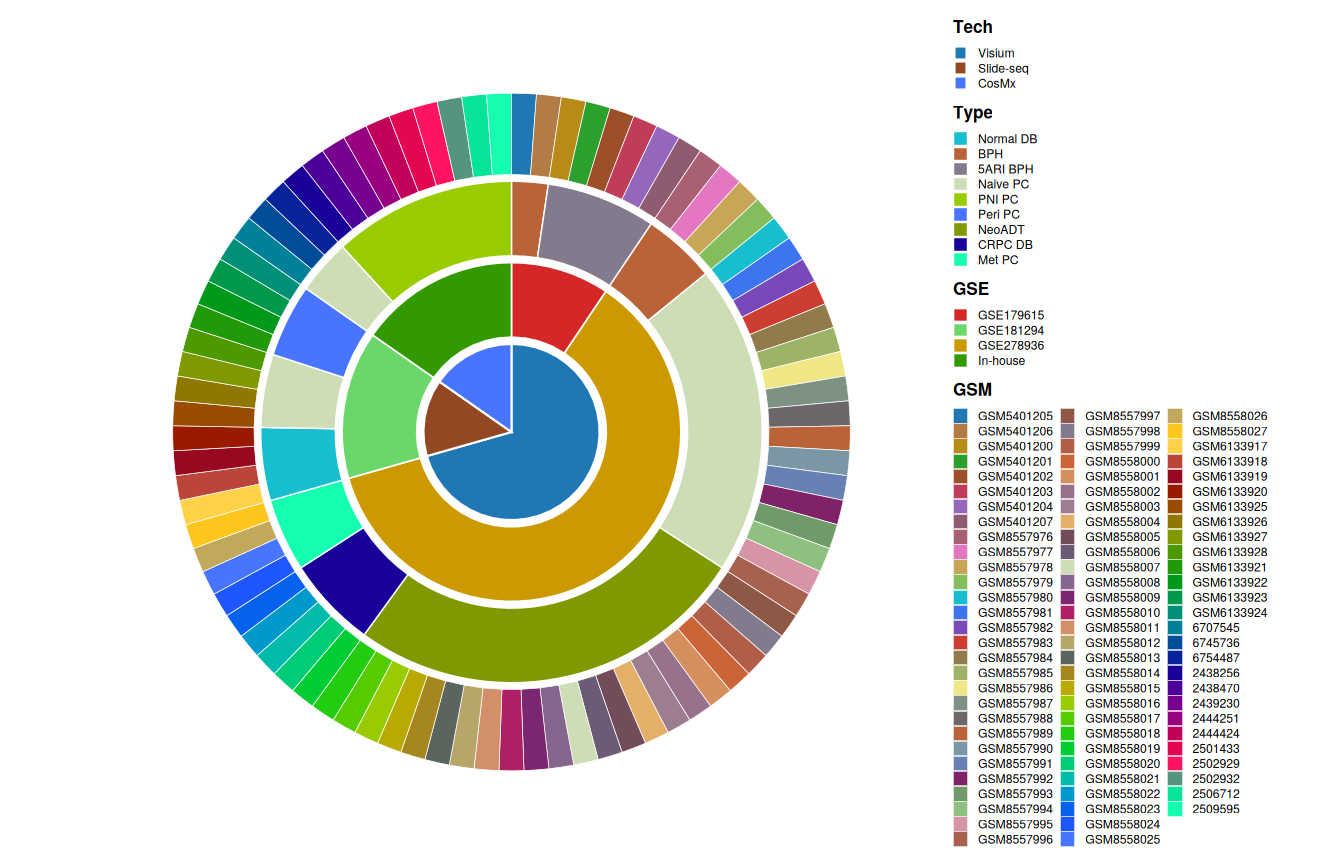

In [24]:
## A 旭日：布局回到 Tech → GSE → Type → GSM（按目录顺序，不按数量堆三大块）。
## 配色参考网页 D3 category20 + IGV51，同层错开取色，避免红蓝绿扎堆。
d3_cat20 <- c(
  "#1F77B4", "#AEC7E8", "#FF7F0E", "#FFBB78", "#2CA02C", "#98DF8A",
  "#D62728", "#FF9896", "#9467BD", "#C5B0D5", "#8C564B", "#C49C94",
  "#E377C2", "#F7B6D2", "#7F7F7F", "#C7C7C7", "#BCBD22", "#DBDB8D",
  "#17BECF", "#9EDAE5"
)
igv51 <- c(
  "#5050FF", "#CE3D32", "#749B58", "#F0E685", "#466983", "#BA6338",
  "#5DB1DD", "#802268", "#6BD76B", "#D595A7", "#924822", "#837B8D",
  "#C75127", "#D58F5C", "#7A65A5", "#E4AF69", "#3B1B53", "#CDDEB7",
  "#612A79", "#AE1F63", "#E7C76F", "#5A655E", "#CC9900", "#99CC00",
  "#A9A9A9", "#CC9900", "#99CC00", "#33CC00", "#00CC33", "#00CC99",
  "#0099CC", "#0A47FF", "#4775FF", "#FFC20A", "#FFD147", "#990033",
  "#991A00", "#996600", "#809900", "#339900", "#00991A", "#009966",
  "#008099", "#003399", "#1A0099", "#660099", "#990080", "#D60047",
  "#FF1463", "#00D68F", "#14FFB1"
)
lerp_hex <- function(a, b, t) {
  A <- col2rgb(a)[, 1]; B <- col2rgb(b)[, 1]
  rgb(A[1] + (B[1] - A[1]) * t, A[2] + (B[2] - A[2]) * t,
      A[3] + (B[3] - A[3]) * t, maxColorValue = 255)
}
# 网页底色，但隔一个取，避免 D3 成对的同色系连在一起
hue_src <- unique(c(d3_cat20[seq(1, 19, by = 2)], igv51))
hue_src <- hue_src[!toupper(hue_src) %in% c("#A9A9A9", "#C7C7C7", "#7F7F7F")]
spread_cols <- function(n, offset = 0L) {
  if (n <= 0L) return(character())
  m <- length(hue_src)
  step <- max(1L, floor(m / n))
  hue_src[((offset + (seq_len(n) - 1L) * step) %% m) + 1L]
}
gsm_ramp <- function(n) {
  if (n <= 1L) return(hue_src[1])
  vapply(seq_len(n), function(i) {
    pos <- ((i - 1) / (n - 1)) * (length(hue_src) - 1)
    i0 <- floor(pos) + 1L
    i1 <- min(length(hue_src), i0 + 1L)
    lerp_hex(hue_src[i0], hue_src[i1], pos - floor(pos))
  }, character(1))
}

sun <- copy(sec)
setorder(sun, tech, study, type, id)
n <- nrow(sun)
sun[, xmax := seq_len(n) / n]
sun[, xmin := xmax - 1 / n]
sun[, type_l := factor(unname(type_lab[as.character(type)]),
                       levels = unname(type_lab[type_ord]))]
sun[, id := factor(as.character(id), levels = as.character(id))]
tech_r <- sun[, .(xmin = min(xmin), xmax = max(xmax), n = .N), by = tech]
gse_r <- sun[, .(xmin = min(xmin), xmax = max(xmax), n = .N), by = .(tech, study)]
type_r <- sun[, .(xmin = min(xmin), xmax = max(xmax), n = .N),
              by = .(tech, study, type_l)]
tech_ids <- levels(sun$tech)
gse_ids <- levels(sun$study)
type_ids <- levels(droplevels(sun$type_l))
gsm_ids <- levels(sun$id)
cols_tech_sun <- setNames(spread_cols(length(tech_ids), 0L), tech_ids)
cols_gse <- setNames(spread_cols(length(gse_ids), 3L), gse_ids)
cols_type <- setNames(spread_cols(length(type_ids), 8L), type_ids)
cols_gsm <- setNames(gsm_ramp(length(gsm_ids)), gsm_ids)
p_a <- ggplot() +
  geom_rect(data = tech_r,
            aes(xmin = xmin, xmax = xmax, ymin = 0, ymax = 0.26, fill = tech),
            color = "white", linewidth = 0.45) +
  scale_fill_manual(name = "Tech", values = cols_tech_sun) +
  new_scale_fill() +
  geom_rect(data = gse_r,
            aes(xmin = xmin, xmax = xmax, ymin = 0.28, ymax = 0.50, fill = study),
            color = "white", linewidth = 0.35) +
  scale_fill_manual(name = "GSE", values = cols_gse) +
  new_scale_fill() +
  geom_rect(data = type_r,
            aes(xmin = xmin, xmax = xmax, ymin = 0.52, ymax = 0.74, fill = type_l),
            color = "white", linewidth = 0.3) +
  scale_fill_manual(name = "Type", values = cols_type) +
  new_scale_fill() +
  geom_rect(data = sun,
            aes(xmin = xmin, xmax = xmax, ymin = 0.76, ymax = 1.00, fill = id),
            color = "white", linewidth = 0.15) +
  scale_fill_manual(name = "GSM", values = cols_gsm,
                    guide = guide_legend(ncol = 3)) +
  coord_polar(theta = "x") +
  ylim(0, 1.02) +
  theme_void(base_size = 12) +
  theme(legend.position = "right",
        legend.text = element_text(size = 7),
        legend.title = element_text(size = 10, face = "bold"),
        legend.key.size = unit(0.32, "cm"))
options(repr.plot.width = 11.2, repr.plot.height = 7.2)
p_a


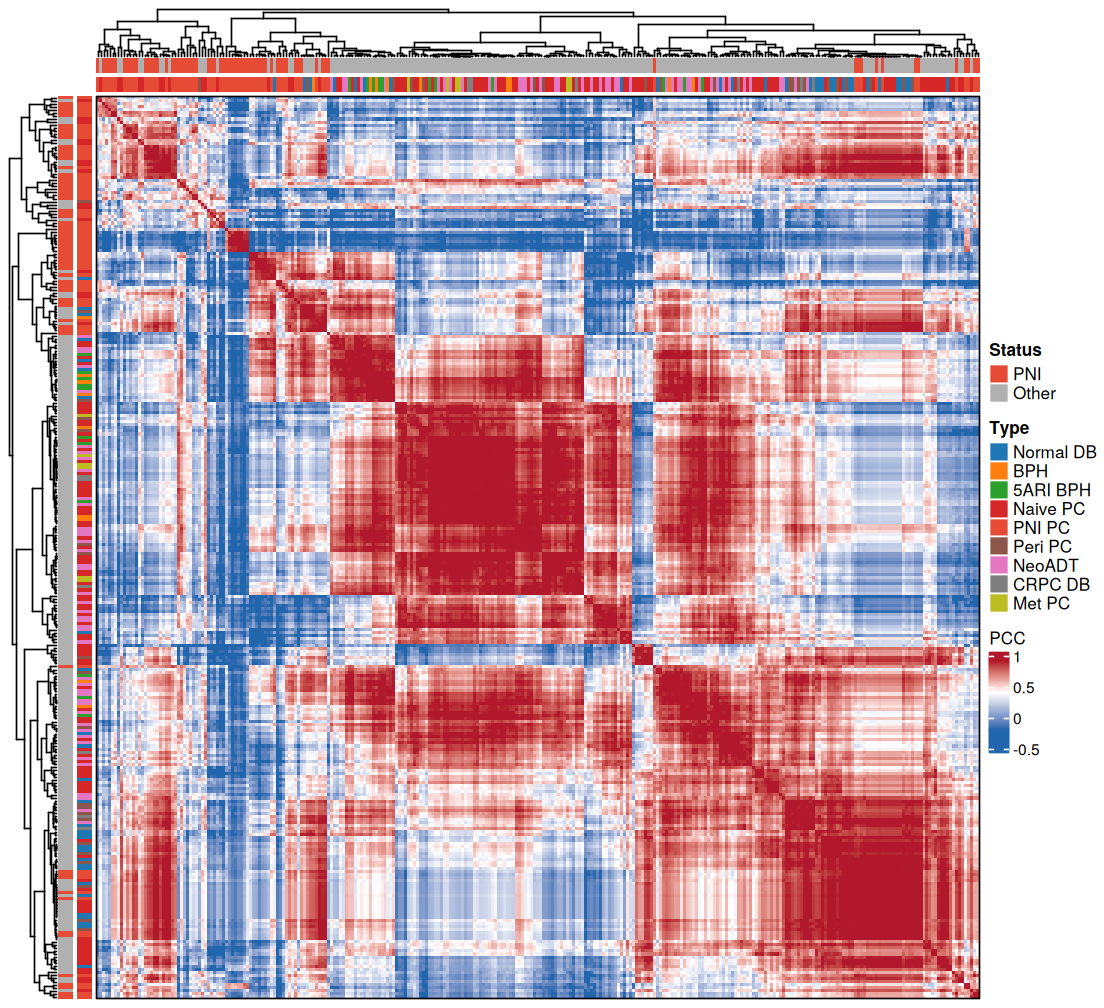

In [22]:
## C 全部切片局部 niche 两两相关。无行列名。
## 行列同一套聚类，才是对称相关图；PNI 独有亚群会在对角线上自己成块。
cos_m <- copy(as.data.table(cos_meta))
cos_m[, `:=`(
  TYPE = fifelse(pni_l == "PNI", "PNI_PC", "Naive_PC"),
  tech = "CosMx",
  status = fifelse(pni_l == "PNI", "PNI", "Other")
)]
pub_m <- copy(as.data.table(pub_meta))
pub_m[, status := "Other"]
meta <- rbind(
  cos_m[, .(col, tech, TYPE, status)],
  pub_m[, .(col, tech, TYPE, status)]
)
all_m <- cbind(cos_bg, pub_c)[, meta$col, drop = FALSE]
meta[, TYPE_l := factor(unname(type_lab[as.character(TYPE)]),
                        levels = unname(type_lab[type_ord]))]
meta[, status := factor(status, levels = c("PNI", "Other"))]
meta[, tech := factor(tech, levels = c("CosMx", "Slide-seq", "Visium"))]
cor_d <- cor(all_m, use = "pairwise.complete.obs")
hc <- hclust(as.dist(1 - cor_d), method = "complete")
type_cols <- setNames(
  substr(pal_d3("category20")(length(type_ord)), 1, 7),
  unname(type_lab[type_ord])
)
type_cols[["PNI PC"]] <- "#E64B35"
cols_status <- c(PNI = "#E64B35", Other = "#B0B0B0")
anno_col <- list(Status = cols_status, Type = type_cols)
ha_r <- rowAnnotation(
  Status = meta$status,
  Type = meta$TYPE_l,
  col = anno_col,
  na_col = "grey80",
  show_annotation_name = FALSE,
  simple_anno_size = unit(3, "mm"),
  gap = unit(1, "mm")
)
ha_t <- HeatmapAnnotation(
  Status = meta$status,
  Type = meta$TYPE_l,
  col = anno_col,
  na_col = "grey80",
  show_annotation_name = FALSE,
  simple_anno_size = unit(3, "mm"),
  gap = unit(1, "mm"),
  annotation_legend_param = list(
    Status = list(title = "Status"),
    Type = list(title = "Type")
  )
)
col_d <- colorRamp2(c(-0.2, 0.4, 0.9), c("#2166AC", "white", "#B2182B"))
options(repr.plot.width = 9.2, repr.plot.height = 8.4)
ht_c <- Heatmap(
  cor_d,
  name = "PCC",
  col = col_d,
  cluster_rows = hc,
  cluster_columns = hc,
  left_annotation = ha_r,
  top_annotation = ha_t,
  show_row_names = FALSE,
  show_column_names = FALSE,
  border = TRUE,
  heatmap_legend_param = list(title_gp = gpar(fontsize = 10),
                              labels_gp = gpar(fontsize = 9))
)
draw(ht_c, merge_legend = TRUE)


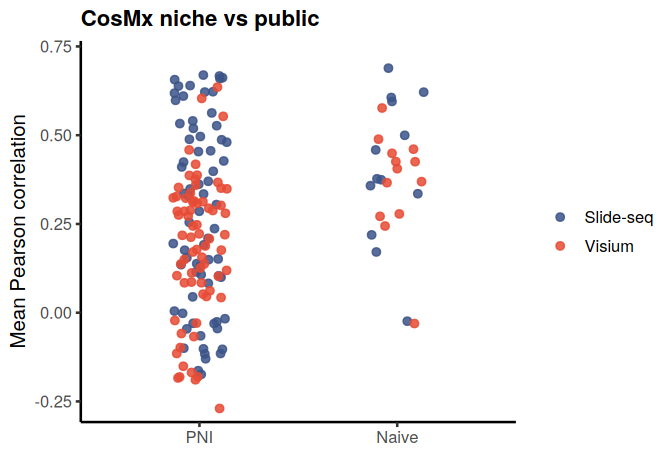

In [27]:
## D 每个 CosMx 局部 niche 对公开的平均相关，按 PNI / Naive。
ss_cols <- intersect(pub_meta[tech == "Slide-seq", col], colnames(cor_cp))
vv_cols <- intersect(pub_meta[tech == "Visium", col], colnames(cor_cp))
mean_of <- function(cols) {
  apply(cor_cp[cos_meta$col, cols, drop = FALSE], 1, function(x) mean(x, na.rm = TRUE))
}
dot <- rbind(
  cos_meta[, .(pni_l, cor = mean_of(ss_cols), tech = "Slide-seq")],
  cos_meta[, .(pni_l, cor = mean_of(vv_cols), tech = "Visium")]
)
dot[, pni_l := factor(pni_l, levels = c("PNI", "Naive"))]
dot[, tech := factor(tech, levels = c("Slide-seq", "Visium"))]
p_d <- ggplot(dot, aes(pni_l, cor, colour = tech)) +
  geom_jitter(width = 0.14, height = 0, size = 1.7, alpha = 0.85) +
  stat_summary(fun = median, geom = "crossbar", width = 0.55,
               linewidth = 0.35, fatten = 0, colour = "grey20") +
  scale_colour_manual(values = c(`Slide-seq` = "#3C5488", Visium = "#E64B35")) +
  scale_y_continuous(expand = expansion(mult = c(0.04, 0.08))) +
  th +
  theme(legend.position = "right",
        axis.title.x = element_blank(),
        plot.title = element_text(face = "bold", size = 13, hjust = 0.5)) +
  labs(y = "Mean Pearson correlation", colour = NULL,
       title = "CosMx niche vs public")
options(repr.plot.width = 5.6, repr.plot.height = 3.8)
p_d


      cl     n n_pni  frac_pni       med_sw
   <int> <int> <int>     <num>        <num>
1:     3     8     8 1.0000000 0.0889393775
2:     1    43    31 0.7209302 0.0037051882
3:     4    49    18 0.3673469 0.0042357266
4:     2   116    13 0.1120690 0.0008479111
5:     5    79     0 0.0000000 0.0046654325


k=5 from C-tree; Unique cluster = 3



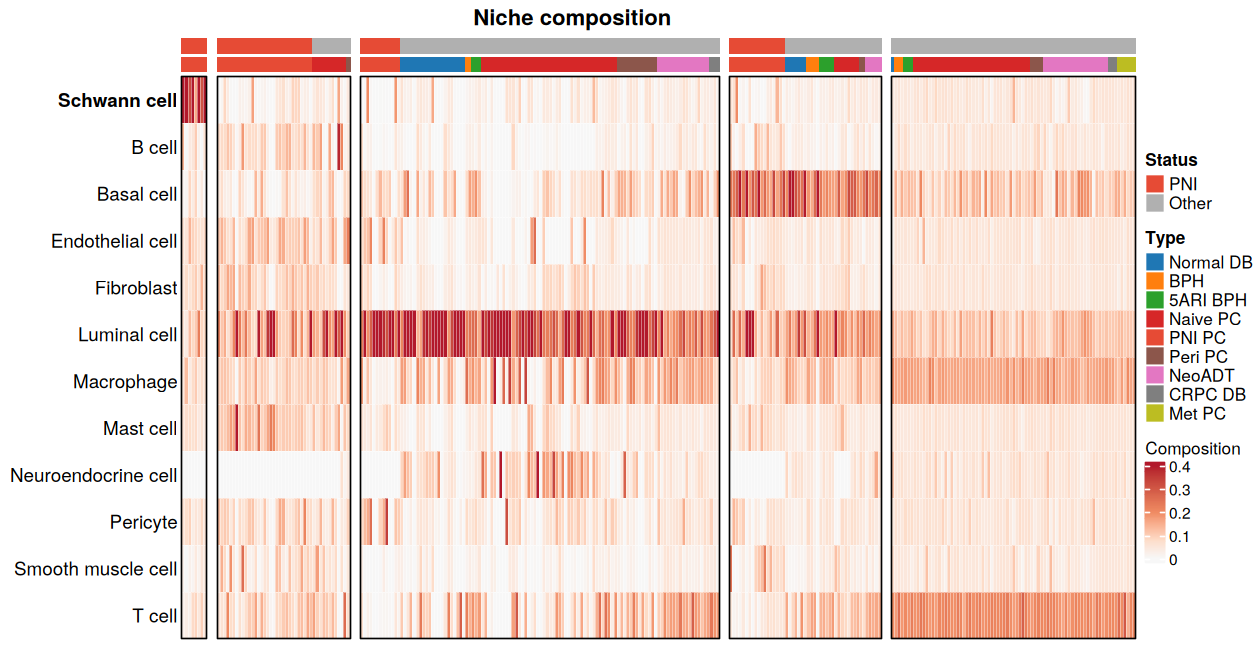

In [43]:
## E 按 C 同一套相关树 cutree(k=5) 切亚型，再画组成。
## 行=细胞类型全名，列=niche；五类切开，总标题保留，不单独标 Unique。
cos_m <- copy(as.data.table(cos_meta))
cos_m[, `:=`(
  TYPE = fifelse(pni_l == "PNI", "PNI_PC", "Naive_PC"),
  tech = "CosMx",
  status = fifelse(pni_l == "PNI", "PNI", "Other")
)]
pub_m <- copy(as.data.table(pub_meta))
pub_m[, status := "Other"]
meta <- rbind(
  cos_m[, .(col, tech, TYPE, status, schwann)],
  pub_m[, .(col, tech, TYPE, status, schwann = NA_real_)]
)
if (!is.null(pub_sw) && nrow(pub_sw)) {
  ps <- copy(as.data.table(pub_sw))
  meta[ps, schwann := i.schwann, on = "col"]
}
all_m <- cbind(cos_bg, pub_c)[, meta$col, drop = FALSE]
meta[, TYPE_l := factor(unname(type_lab[as.character(TYPE)]),
                        levels = unname(type_lab[type_ord]))]
meta[, status := factor(status, levels = c("PNI", "Other"))]
meta[, tech := factor(tech, levels = c("CosMx", "Slide-seq", "Visium"))]
if (exists("hc") && inherits(hc, "hclust") &&
    exists("cor_d") && all(colnames(cor_d) %in% meta$col)) {
  hc_e <- hc
} else {
  hc_e <- hclust(as.dist(1 - cor(all_m, use = "pairwise.complete.obs")),
                 method = "complete")
}
meta[, cl := cutree(hc_e, k = 5)[col]]
stat_e <- meta[, .(n = .N, n_pni = sum(status == "PNI"),
                   frac_pni = mean(status == "PNI"),
                   med_sw = median(schwann, na.rm = TRUE)), by = cl]
uniq_cl <- stat_e[frac_pni >= 0.99][which.max(med_sw), cl]
oth <- setdiff(sort(unique(meta$cl)), uniq_cl)
meta[, slice := factor(
  fifelse(cl == uniq_cl, "Unique", paste0("c", cl)),
  levels = c("Unique", paste0("c", oth))
)]
setorder(meta, slice, status, TYPE_l, tech, col)
all_m <- cbind(cos_bg, pub_c)[, meta$col, drop = FALSE]
ct_ord <- c("Schwann cell", setdiff(align_lv, "Schwann cell"))
mat_e <- all_m[ct_ord, meta$col, drop = FALSE]
type_cols <- setNames(
  substr(pal_d3("category20")(length(type_ord)), 1, 7),
  unname(type_lab[type_ord])
)
type_cols[["PNI PC"]] <- "#E64B35"
cols_status <- c(PNI = "#E64B35", Other = "#B0B0B0")
ha_e <- HeatmapAnnotation(
  Status = meta$status,
  Type = meta$TYPE_l,
  col = list(Status = cols_status, Type = type_cols),
  na_col = "grey80",
  show_annotation_name = FALSE,
  simple_anno_size = unit(3, "mm"),
  gap = unit(1, "mm")
)
col_e <- colorRamp2(c(0, 0.08, 0.20, 0.40),
                    c("#F7F7F7", "#FDDBC7", "#EF8A62", "#B2182B"))
row_face <- ifelse(rownames(mat_e) == "Schwann cell", "bold", "plain")
options(repr.plot.width = 10.5, repr.plot.height = 5.4)
ht_e <- Heatmap(
  mat_e, name = "Composition", col = col_e,
  cluster_rows = FALSE, cluster_columns = FALSE,
  column_split = meta$slice,
  column_gap = unit(2.2, "mm"),
  cluster_column_slices = FALSE,
  column_title = NULL,
  top_annotation = ha_e,
  show_row_names = TRUE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = 11, fontface = row_face),
  row_names_side = "left",
  border = TRUE,
  rect_gp = gpar(col = "white", lwd = 0.25),
  heatmap_legend_param = list(title_gp = gpar(fontsize = 10),
                              labels_gp = gpar(fontsize = 9))
)
grid.newpage()
draw(ht_e, merge_legend = TRUE,
     column_title = "Niche composition",
     column_title_gp = gpar(fontsize = 13, fontface = "bold"))
print(stat_e[order(-frac_pni, -med_sw)])
message("k=5 from C-tree; Unique cluster = ", uniq_cl)


      grp      tech     n          med          q25         q75
   <fctr>    <fctr> <int>        <num>        <num>       <num>
1: Unique     CosMx     8 0.0889393775 6.663290e-02 0.141715669
2:  Other     CosMx    75 0.0035418261 4.068272e-04 0.008208459
3:  Other Slide-seq    98 0.0007814261 7.795881e-05 0.002379837
4:  Other    Visium   114 0.0048214796 3.280012e-03 0.007349528


Unique n=8 Other n=287  P = 1.8e-06



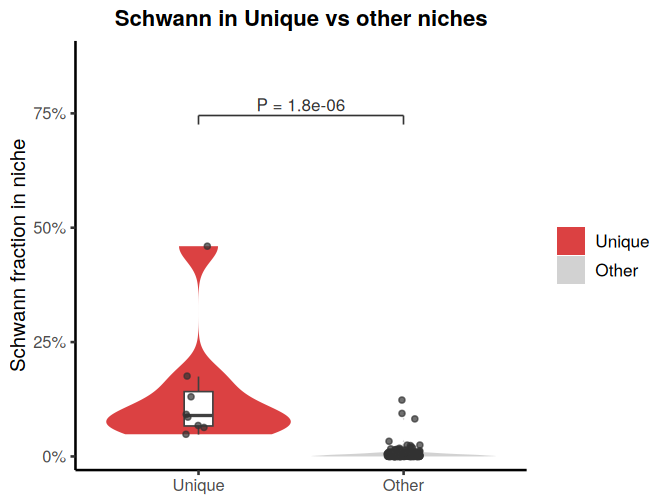

In [64]:
## F Unique vs 其余 niche 的施万比例。全部切片（CosMx + Visium + Slide-seq）。
## 分组来自 C 同一套相关树 cutree(k=5)，不按 PNI/Naive。
suppressPackageStartupMessages(library(ggsignif))
cos_m <- copy(as.data.table(cos_meta))
cos_m[, `:=`(
  tech = "CosMx",
  status = fifelse(pni_l == "PNI", "PNI", "Other")
)]
pub_m <- copy(as.data.table(pub_meta))
pub_m[, status := "Other"]
meta_f <- rbind(
  cos_m[, .(col, tech, status, schwann)],
  pub_m[, .(col, tech, status, schwann = NA_real_)]
)
if (!is.null(pub_sw) && nrow(pub_sw)) {
  ps <- copy(as.data.table(pub_sw))
  meta_f[ps, schwann := i.schwann, on = "col"]
}
all_m <- cbind(cos_bg, pub_c)[, meta_f$col, drop = FALSE]
if (exists("hc") && inherits(hc, "hclust") &&
    exists("cor_d") && all(colnames(cor_d) %in% meta_f$col)) {
  hc_f <- hc
} else {
  hc_f <- hclust(as.dist(1 - cor(all_m, use = "pairwise.complete.obs")),
                 method = "complete")
}
meta_f[, cl := cutree(hc_f, k = 5)[col]]
stat_f <- meta_f[, .(frac_pni = mean(status == "PNI"),
                     med_sw = median(schwann, na.rm = TRUE)), by = cl]
uniq_cl <- stat_f[frac_pni >= 0.99][which.max(med_sw), cl]
meta_f[, grp := factor(fifelse(cl == uniq_cl, "Unique", "Other"),
                       levels = c("Unique", "Other"))]
meta_f[, tech := factor(tech, levels = c("CosMx", "Slide-seq", "Visium"))]
sw <- meta_f[is.finite(schwann)]
p_u <- wilcox.test(sw[grp == "Unique", schwann], sw[grp == "Other", schwann],
                   exact = FALSE)$p.value
plab <- ifelse(p_u < 2.2e-16, "P < 2.2e-16",
               sprintf("P = %s", formatC(p_u, format = "g", digits = 2)))
## 两两比较括号：与 12 脚本 br_of 相同（ymax*1.22，小短竖 dy=ymax*0.04），不额外留空。
ymax <- max(sw$schwann, na.rm = TRUE)
br <- data.table(xmin = 1, xmax = 2, y = ymax * 1.62, dy = ymax * 0.04, lab = plab)
p_f <- ggplot(sw, aes(grp, schwann, fill = grp)) +
  geom_violin(scale = "width", trim = TRUE, color = NA, alpha = 0.88, width = 0.9) +
  geom_boxplot(width = 0.14, outlier.shape = NA, fill = "white",
               color = "grey25", linewidth = 0.35) +
  geom_jitter(width = 0.08, size = 1.1, alpha = 0.7, color = "grey20",
              show.legend = FALSE) +
  geom_segment(data = br, aes(x = xmin, xend = xmax, y = y, yend = y),
               linewidth = 0.35, colour = "grey20", inherit.aes = FALSE) +
  geom_segment(data = br, aes(x = xmin, xend = xmin, y = y, yend = y - dy),
               linewidth = 0.35, colour = "grey20", inherit.aes = FALSE) +
  geom_segment(data = br, aes(x = xmax, xend = xmax, y = y, yend = y - dy),
               linewidth = 0.35, colour = "grey20", inherit.aes = FALSE) +
  geom_text(data = br, aes(x = (xmin + xmax) / 2, y = y, label = lab),
            vjust = -0.35, size = 3.5, colour = "grey20", inherit.aes = FALSE) +
  scale_fill_manual(values = c(Unique = "#D62728", Other = "grey80")) +
  guides(fill = guide_legend(override.aes = list(shape = NA, colour = NA))) +
  scale_y_continuous(labels = percent_format(accuracy = 1),
                     expand = expansion(mult = c(0.04, 0.22))) +
  th +
  theme(legend.position = "right",
        legend.text = element_text(size = 10),
        legend.title = element_blank(),
        plot.title = element_text(face = "bold", size = 13, hjust = 0.5),
        axis.title.x = element_blank()) +
  labs(y = "Schwann fraction in niche", fill = NULL,
       title = "Schwann in Unique vs other niches")
options(repr.plot.width = 5.6, repr.plot.height = 4.2)
p_f
print(sw[, .(n = .N, med = median(schwann),
             q25 = quantile(schwann, 0.25), q75 = quantile(schwann, 0.75)),
         by = .(grp, tech)][order(grp, tech)])
message("Unique n=", sw[grp == "Unique", .N],
        " Other n=", sw[grp == "Other", .N], "  ", plab)

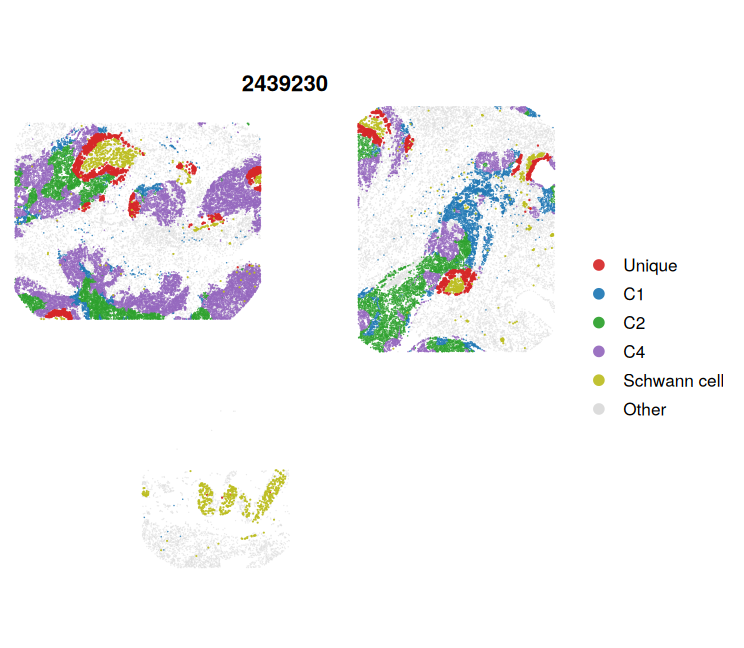

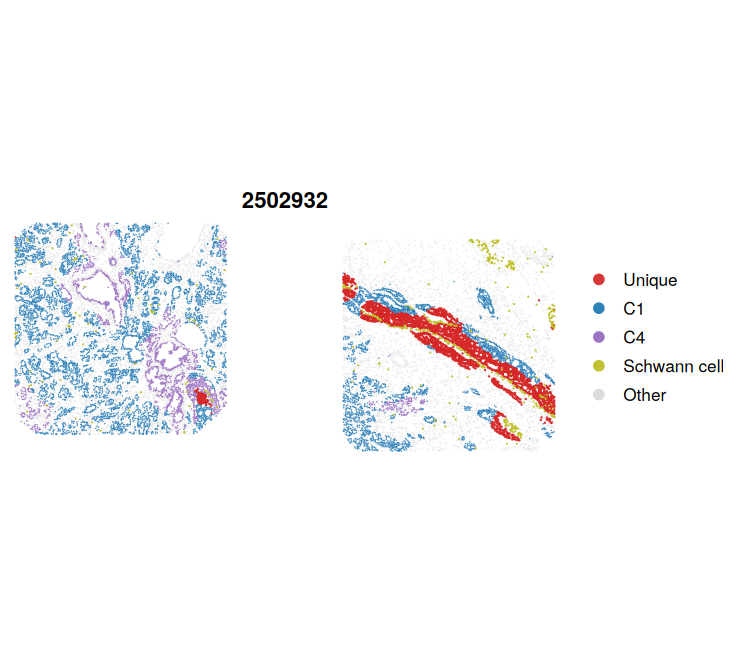

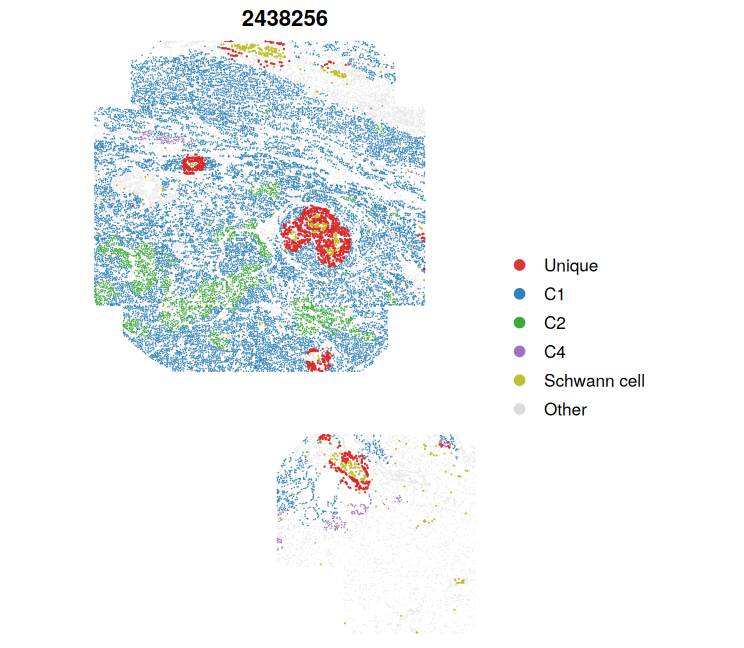

     sample          grp     N
     <fctr>       <fctr> <int>
 1: 2439230       Unique  2212
 2: 2439230           C1  4256
 3: 2439230           C2  7973
 4: 2439230           C4 15800
 5: 2439230 Schwann cell  1485
 6: 2439230        Other 23865
 7: 2502932       Unique  2435
 8: 2502932           C1  7556
 9: 2502932           C4  1927
10: 2502932 Schwann cell   468
11: 2502932        Other 11129
12: 2438256       Unique  1114
13: 2438256           C1 16612
14: 2438256           C2  2512
15: 2438256           C4   272
16: 2438256 Schwann cell   452
17: 2438256        Other 14339
18: 2444424       Unique   855
19: 2444424           C1 11486
20: 2444424           C2    27
21: 2444424           C4  4084
22: 2444424 Schwann cell  1330
23: 2444424        Other 18279
     sample          grp     N


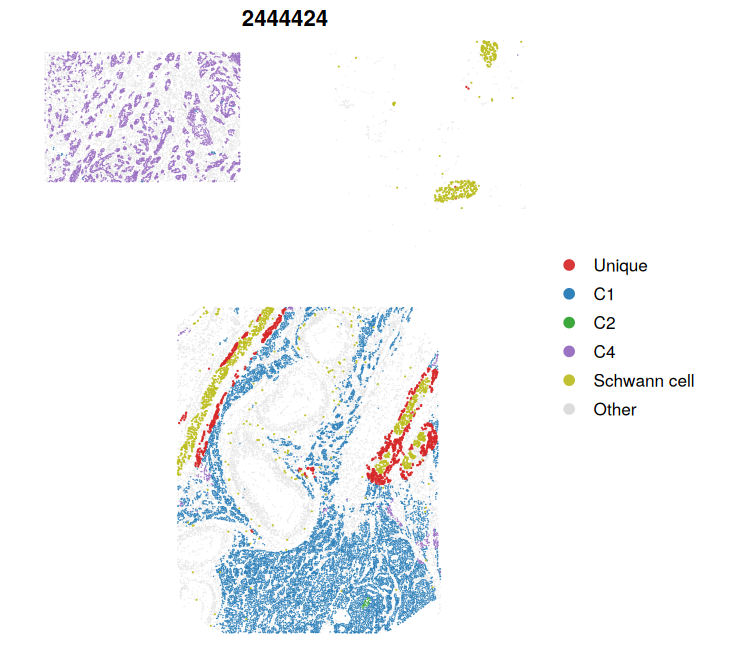

In [ ]:
## G 四张 PNI 切片空间图，各画一张。上皮亚群+施万上色，其余细胞灰色。
## 本格自算 cutree(k=5)，不依赖已删的 Unique 来源图。
xy_rds <- file.path(outd, "cosmx_xy_spatial.rds")
qs_dir <- file.path(root, "vis/data/processed/spatial_img/cosmx_by_sample")
sns_h <- c("2439230", "2502932", "2438256", "2444424")

cos_m <- copy(as.data.table(cos_meta))
cos_m[, `:=`(
  tech = "CosMx",
  status = fifelse(pni_l == "PNI", "PNI", "Other")
)]
pub_m <- copy(as.data.table(pub_meta))
pub_m[, status := "Other"]
meta_cl <- rbind(
  cos_m[, .(col, tech, status, sample, schwann)],
  pub_m[, .(col, tech, status, sample = NA_character_, schwann = NA_real_)]
)
all_m <- cbind(cos_bg, pub_c)[, meta_cl$col, drop = FALSE]
if (exists("hc") && inherits(hc, "hclust") &&
    exists("cor_d") && all(colnames(cor_d) %in% meta_cl$col)) {
  hc_g <- hc
} else {
  hc_g <- hclust(as.dist(1 - cor(all_m, use = "pairwise.complete.obs")),
                 method = "complete")
}
meta_cl[, cl := cutree(hc_g, k = 5)[col]]
stat_g <- meta_cl[, .(frac_pni = mean(status == "PNI"),
                      med_sw = median(schwann, na.rm = TRUE)), by = cl]
uniq_cl <- stat_g[frac_pni >= 0.99][which.max(med_sw), cl]
oth <- setdiff(sort(unique(meta_cl$cl)), uniq_cl)
meta_cl[, slice := factor(
  fifelse(cl == uniq_cl, "Unique", paste0("C", cl)),
  levels = c("Unique", paste0("C", oth))
)]
cos_cl <- meta_cl[tech == "CosMx"]

need <- sns_h
if (file.exists(xy_rds)) {
  xy_have <- unique(as.data.table(readRDS(xy_rds))$sample)
  need <- setdiff(sns_h, xy_have)
}
if (length(need)) {
  suppressPackageStartupMessages({ library(Seurat); library(qs) })
  if (!exists("slim") || is.null(slim)) slim <- readRDS(slim_rds)
  rows <- if (file.exists(xy_rds)) list(as.data.table(readRDS(xy_rds))) else list()
  for (sn in need) {
    seu <- qread(file.path(qs_dir, paste0(sn, ".qs")), nthreads = 8L)
    xy <- as.matrix(Embeddings(seu, "spatial"))
    dt <- data.table(
      cell = colnames(seu),
      x = as.numeric(xy[, 1]), y = as.numeric(xy[, 2]),
      annotation = as.character(seu$annotation), sample = sn
    )
    md <- as.data.table(slim[[sn]]$meta, keep.rownames = "cell")
    dt[md, epi.sub := i.epi.sub, on = "cell"]
    rows[[length(rows) + 1L]] <- dt
    rm(seu); gc(verbose = FALSE)
  }
  saveRDS(rbindlist(rows, use.names = TRUE, fill = TRUE), xy_rds)
}
xy3 <- as.data.table(readRDS(xy_rds))[sample %in% sns_h]
xy3[, epi.sub := as.character(epi.sub)]
xy3[, niche := fifelse(!is.na(epi.sub) & nzchar(epi.sub),
                       paste0(sample, "_", epi.sub), NA_character_)]
xy3[cos_cl, slice := i.slice, on = c("niche" = "col")]
xy3[, grp := "Other"]
xy3[!is.na(slice), grp := as.character(slice)]
xy3[annotation == "Schwann cell", grp := "Schwann cell"]
grp_lv <- c(levels(cos_cl$slice), "Schwann cell", "Other")
xy3[, grp := factor(grp, levels = grp_lv)]
xy3[, z := fcase(grp == "Other", 0L, grp == "Schwann cell", 3L,
                 grp == "Unique", 2L, default = 1L)]
setorder(xy3, sample, z)
d3_h <- substr(pal_d3("category20")(20), 1, 7)
cl_lv <- setdiff(grp_lv, c("Unique", "Schwann cell", "Other"))
pal_h <- c(Unique = d3_h[4], `Schwann cell` = d3_h[9], Other = "grey85")
pal_h[cl_lv] <- d3_h[c(1, 3, 5, 7, 11, 13)][seq_along(cl_lv)]
xy3[, sample := factor(sample, levels = sns_h)]
show_lv <- intersect(grp_lv, unique(as.character(xy3$grp)))
spat_one <- function(sn) {
  d <- xy3[sample == sn]
  ggplot(d, aes(x, y, colour = grp)) +
    geom_point(data = d[z == 0L], size = 0.12, stroke = 0, alpha = 0.55) +
    geom_point(data = d[z == 1L], size = 0.16, stroke = 0, alpha = 0.85) +
    geom_point(data = d[z == 2L], size = 0.38, stroke = 0, alpha = 0.95) +
    geom_point(data = d[z == 3L], size = 0.32, stroke = 0, alpha = 0.95) +
    scale_colour_manual(values = pal_h, breaks = show_lv, drop = TRUE) +
    guides(colour = guide_legend(
      override.aes = list(size = 3.0, alpha = 0.92, stroke = 0))) +
    coord_equal(expand = FALSE) +
    th +
    theme(axis.title = element_blank(),
          axis.text = element_blank(),
          axis.ticks = element_blank(),
          axis.line = element_blank(),
          legend.position = "right",
          legend.text = element_text(size = 10),
          legend.title = element_blank(),
          plot.title = element_text(face = "bold", size = 13, hjust = 0.5)) +
    labs(colour = NULL, title = sn)
}
options(repr.plot.width = 6.2, repr.plot.height = 5.4)
for (sn in sns_h) print(spat_one(sn))
print(xy3[, .N, by = .(sample, grp)][order(sample, grp)])
